In [ ]:
!pip install ultralytics -q

In [ ]:
import cv2
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from collections import defaultdict

In [ ]:
df = pd.read_csv('/content/25_12-20.csv')
df.head()

,filename,product_name,price_default,price_card,price_discount,barcode,discount_amount,id_sku,print_datetime,code,...,price1_qr,price2_qr,price3_qr,price4_qr,wholesale_level_1_count,wholesale_level_1_price,wholesale_level_2_count,wholesale_level_2_price,action_price_qr,action_code_qr
0,25_12-20/2.mp4,Напиток безалкогольный SANTO STEFANO Rosso (Ро...,"252,63","129,99",нет,4670025474665,-48%,270207736530,03.04.2026 3:08,нет,...,252.63,239.99,нет,129.99,нет,нет,нет,нет,нет,нет
1,25_12-20/2.mp4,Напиток безалкогольный SANTO STEFANO Bianco (Р...,"252,63","129,99",нет,4670025474658,-48%,270207736529,03.04.2026 3:08,нет,...,252.63,239.99,нет,129.99,нет,нет,нет,нет,нет,нет
2,25_12-20/2.mp4,Напиток безалкогольный ABRAU LIGHT Аромат. с/г...,"144,99","129,99",нет,4680140271438,-10%,270207716055,04.04.2026 1:09,нет,...,144.99,137.79,нет,129.99,нет,нет,нет,нет,нет,нет
3,25_12-20/2.mp4,Напиток безалкогольный ABRAU LIGHT Аромат. роз...,"144,99","129,99",нет,4680140271469,-10%,270207716056,04.04.2026 1:09,024 017_1_6_2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,25_12-20/2.mp4,Напиток безалкогольный ABRAU LIGHT Zero аромат...,"547,36","259,99",нет,4630027300508,-52%,270207659437,17.03.2026 13:27,нет,...,547.36,519.99,нет,259.99,нет,нет,нет,нет,нет,нет


In [ ]:
# применить замену запятой на точку только для нужных столбцов
cols_to_fix = ['y_min', 'x_min', 'x_max', 'y_max']  # пример
for col in cols_to_fix:
    if col in df.columns:
        # преобразуем в строку, меняем запятую на точку, затем во float
        df[col] = df[col].astype(str).str.replace(',', '.').astype(float)

In [ ]:
df['x_min'].head(5)

,x_min
0,2063.1
1,2098.8
2,2125.1
3,2148.0
4,2061.3


In [ ]:
df.shape[0]

57

In [ ]:
def xyxy_to_yolo(xyxy_box, img_width, img_height):
    """
    Конвертирует [x1, y1, x2, y2] в [x_center, y_center, width, height]
    с нормированием относительно размеров изображения
    """
    x1, y1, x2, y2 = xyxy_box

    # Вычисляем центр
    x_center = (x1 + x2) / 2.0
    y_center = (y1 + y2) / 2.0

    # Вычисляем ширину и высоту
    width = x2 - x1
    height = y2 - y1

    # Нормируем относительно размеров изображения
    x_center_norm = x_center / img_width
    y_center_norm = y_center / img_height
    width_norm = width / img_width
    height_norm = height / img_height

    return [x_center_norm, y_center_norm, width_norm, height_norm]

In [ ]:
def create_price_tag_dataset(videos_csv_pairs: list[tuple], output_dir: str = "price_tag_yolo"):
    output_dir = Path(output_dir)
    (output_dir / "images").mkdir(parents=True, exist_ok=True)
    (output_dir / "labels").mkdir(parents=True, exist_ok=True)

    all_annotations = 0
    total_images = 0

    for video_path, csv_path in videos_csv_pairs:
        # Группируем строки CSV по frame_timestamp
        df = pd.read_csv(csv_path, decimal=',')
        rows_by_ts = defaultdict(list)
        for _, row in df.iterrows():
            ts_ms = row['frame_timestamp']
            rows_by_ts[ts_ms].append(row)

        video = cv2.VideoCapture(str(video_path))
        for ts_ms, rows in rows_by_ts.items():
            video.set(cv2.CAP_PROP_POS_MSEC, ts_ms)
            ret, frame = video.read()
            if not ret:
                continue

            h, w = frame.shape[:2]
            img_name = f"{Path(video_path).stem}_ts{int(ts_ms)}.jpg"
            img_path = output_dir / "images" / img_name
            cv2.imwrite(str(img_path), frame)

            label_lines = []
            for row in rows:
                x1 = float(row['x_min'])
                y1 = float(row['y_min'])
                x2 = float(row['x_max'])
                y2 = float(row['y_max'])
                # YOLO формат: class_id center_x center_y width height (нормализованные)
                cx = (x1 + x2) / 2 / w
                cy = (y1 + y2) / 2 / h
                bw = (x2 - x1) / w
                bh = (y2 - y1) / h
                label_lines.append(f"0 {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}")
                all_annotations += 1

            label_path = output_dir / "labels" / f"{img_name.replace('.jpg', '.txt')}"
            with open(label_path, 'w') as f:
                f.write("\n".join(label_lines))

            total_images += 1

        video.release()

    print(f"Создано {total_images} изображений и {all_annotations} аннотаций для YOLO")

    # Создаём data.yaml
    yaml_content = f"""
path: {output_dir.absolute()}
train: images
val: images

nc: 1
names: ['price_tag']
"""
    (output_dir / "data.yaml").write_text(yaml_content)

In [ ]:
create_price_tag_dataset([(
    '/content/25_12-20.mp4',
    '/content/25_12-20.csv')])

Создано 9 изображений и 53 аннотаций для YOLO


In [ ]:
# Функция для отрисовки тренировочных данных
def demonstrate_train_data(
    image_path: str,
    label_path: str
    ) -> Figure:

    # Загрузка изображения
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Конвертация в RGB для matplotlib
    h, w = image.shape[:2]

    # Чтение меток
    with open(label_path, 'r') as f:
        labels = f.readlines()

    # Отрисовка bounding boxes
    for label in labels:
        class_id, x_center, y_center, width, height = map(float, label.split())
        class_id = int(class_id)

        # Конвертация из YOLO-формата (нормированные координаты) в пиксели
        x_center *= w
        y_center *= h
        width *= w
        height *= h
        x1 = int(x_center - width/2)
        y1 = int(y_center - height/2)
        x2 = int(x_center + width/2)
        y2 = int(y_center + height/2)

        # Рисуем прямоугольник и подпись
        cv2.rectangle(image, (x1, y1), (x2, y2), colors[class_id], 10)
        cv2.putText(image, classes[class_id], (x1, y1-10),
                cv2.FONT_HERSHEY_SIMPLEX, 2, colors[class_id], 2)

    # Вывод изображения
    fig = plt.figure(figsize=(14,10))
    array = np.array(image)
    plt.imshow(array, cmap='gray')
    plt.colorbar()
    plt.axis('off')
    plt.close(fig)

    return fig

In [ ]:
classes = ['price_tag']
colors = [(255,0,0)]

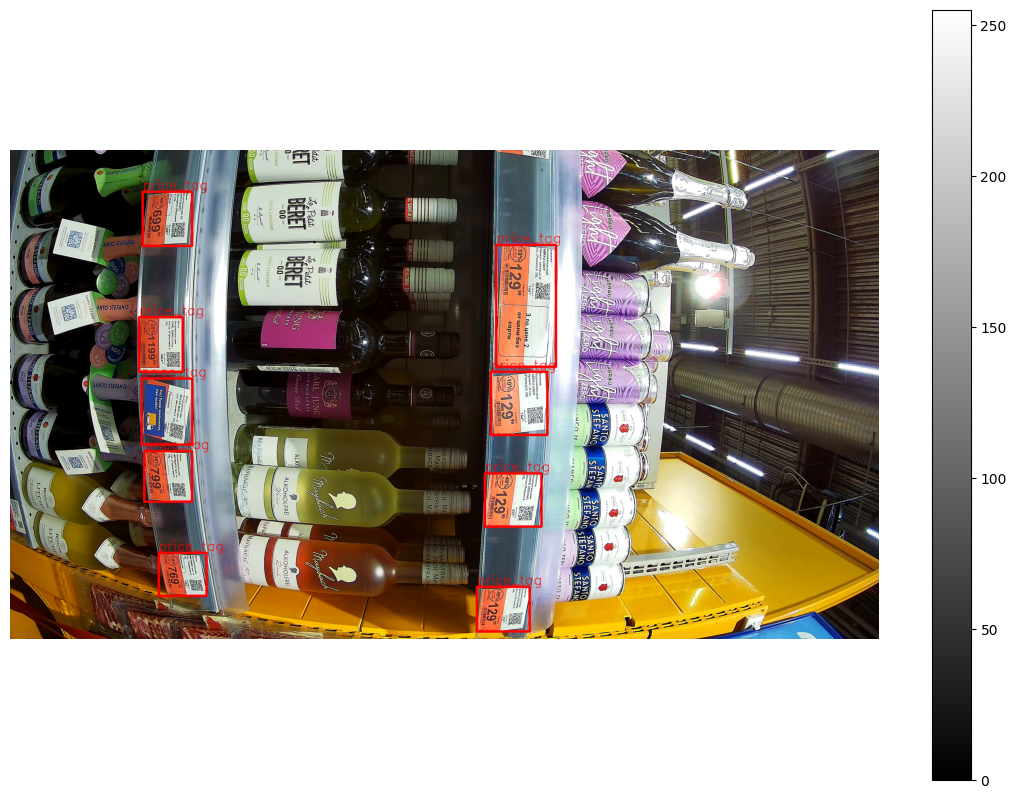

In [ ]:
image_path = '/content/price_tag_yolo/images/25_12-20_ts0.jpg'
label_path = '/content/price_tag_yolo/labels/25_12-20_ts0.txt'

demonstrate_train_data(image_path, label_path)

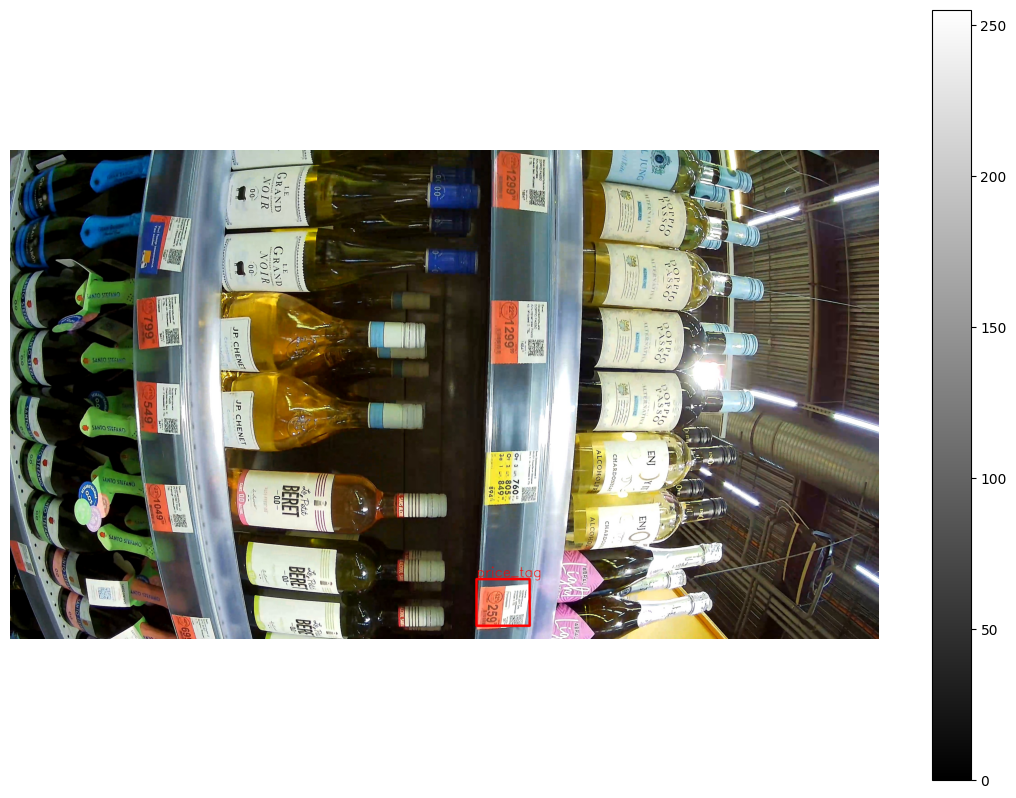

In [ ]:
image_path = '/content/price_tag_yolo/images/25_12-20_ts5745.jpg'
label_path = '/content/price_tag_yolo/labels/25_12-20_ts5745.txt'

demonstrate_train_data(image_path, label_path)

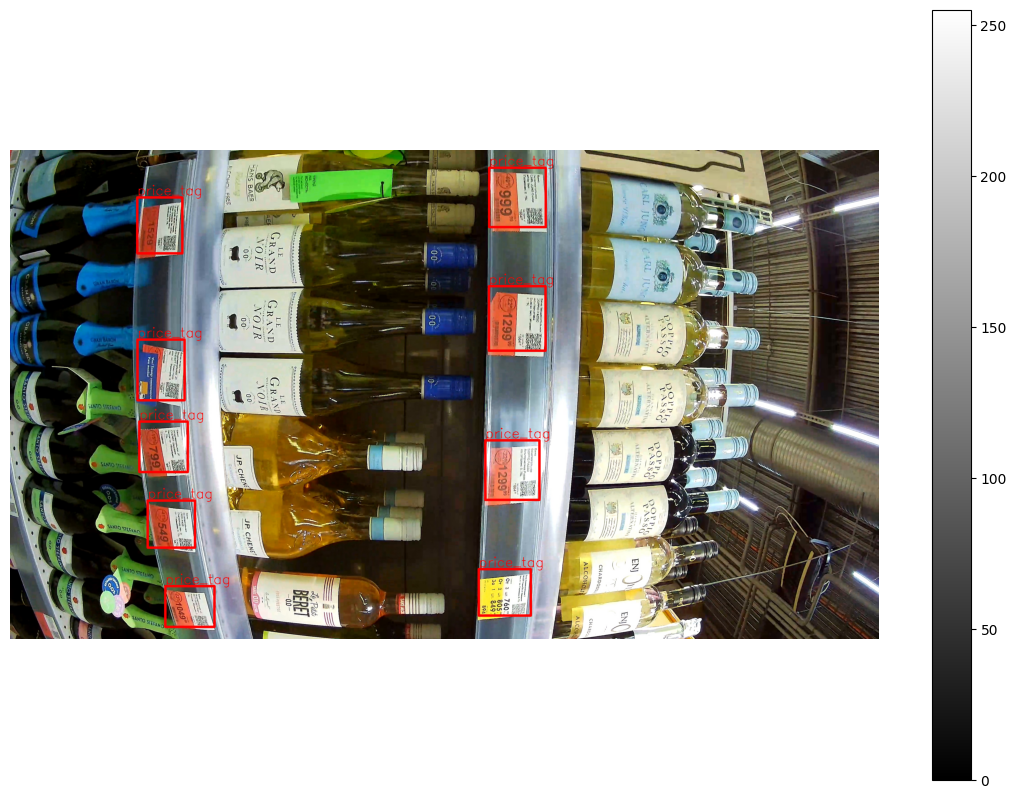

In [ ]:
image_path = '/content/price_tag_yolo/images/25_12-20_ts7168.jpg'
label_path = '/content/price_tag_yolo/labels/25_12-20_ts7168.txt'

demonstrate_train_data(image_path, label_path)

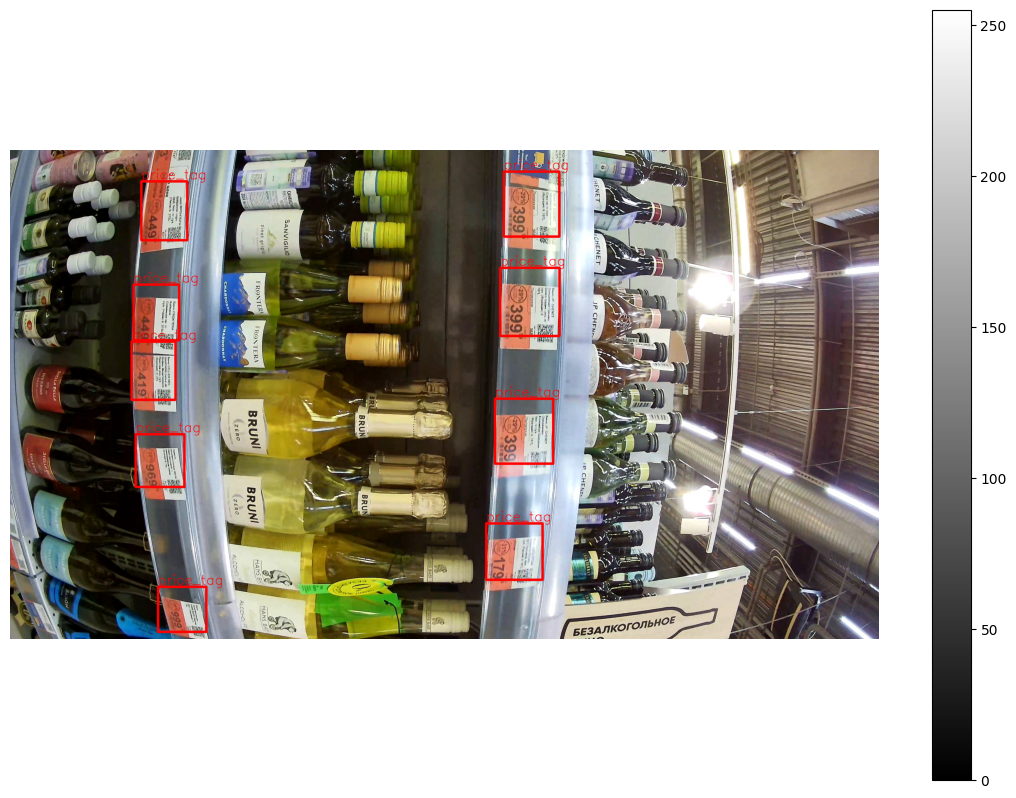

In [ ]:
image_path = '/content/price_tag_yolo/images/25_12-20_ts12506.jpg'
label_path = '/content/price_tag_yolo/labels/25_12-20_ts12506.txt'

demonstrate_train_data(image_path, label_path)

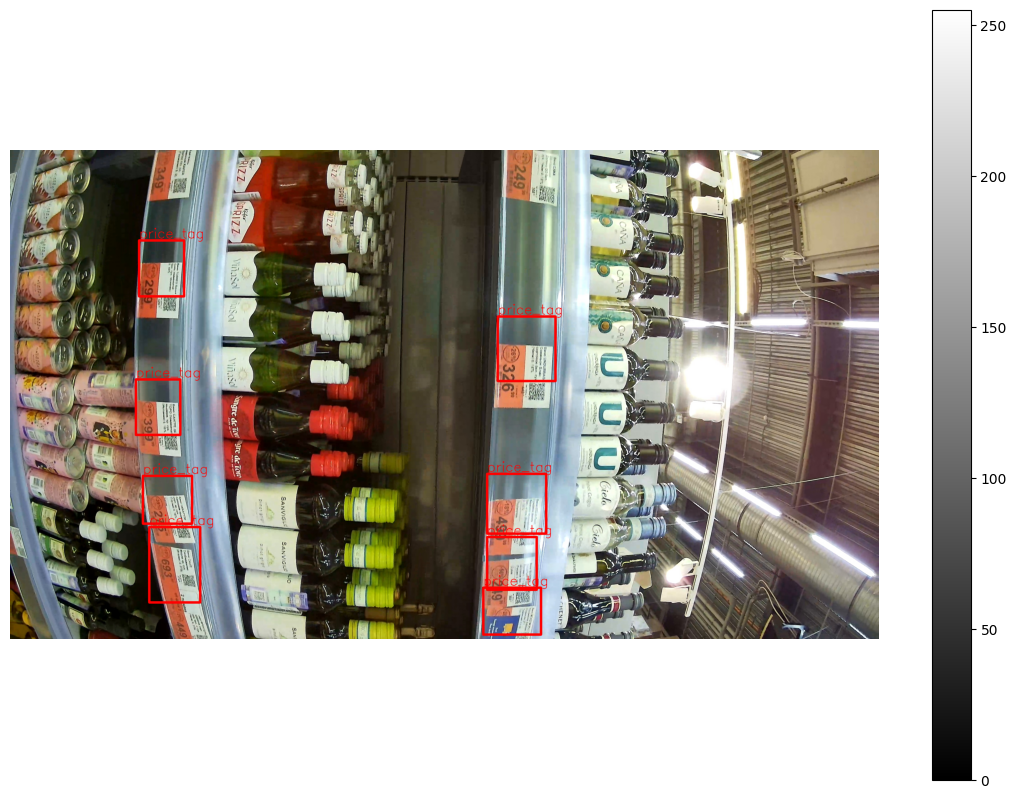

In [ ]:
image_path = '/content/price_tag_yolo/images/25_12-20_ts16929.jpg'
label_path = '/content/price_tag_yolo/labels/25_12-20_ts16929.txt'

demonstrate_train_data(image_path, label_path)

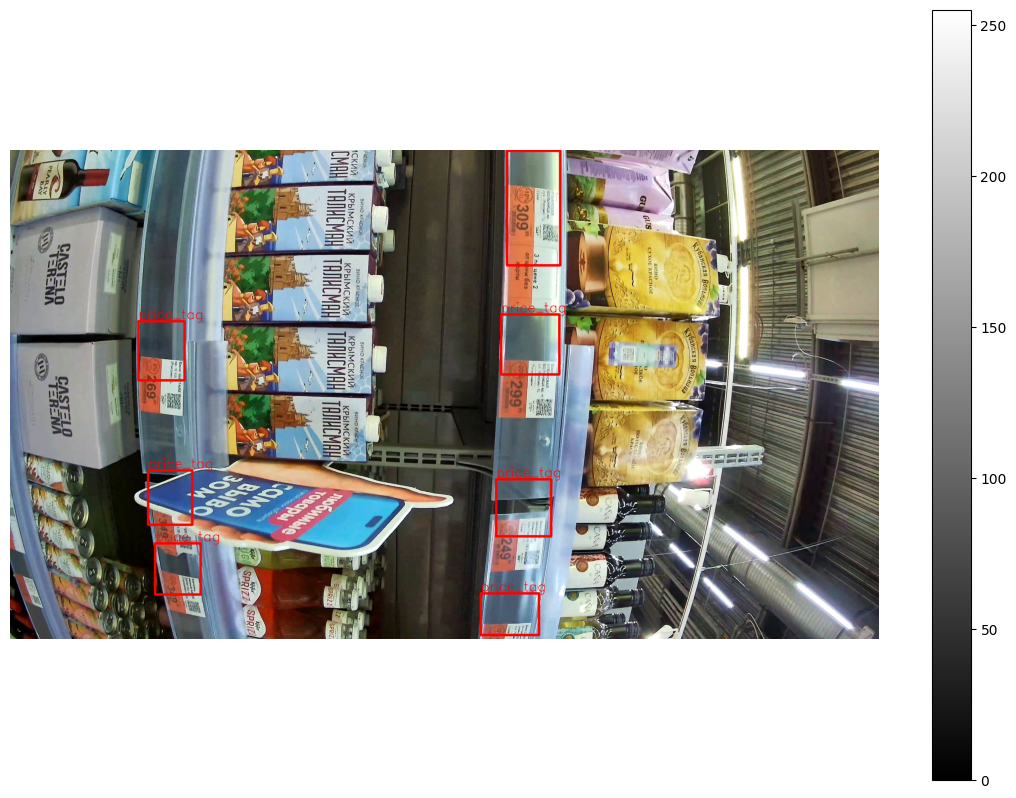

In [ ]:
image_path = '/content/price_tag_yolo/images/25_12-20_ts21251.jpg'
label_path = '/content/price_tag_yolo/labels/25_12-20_ts21251.txt'

demonstrate_train_data(image_path, label_path)

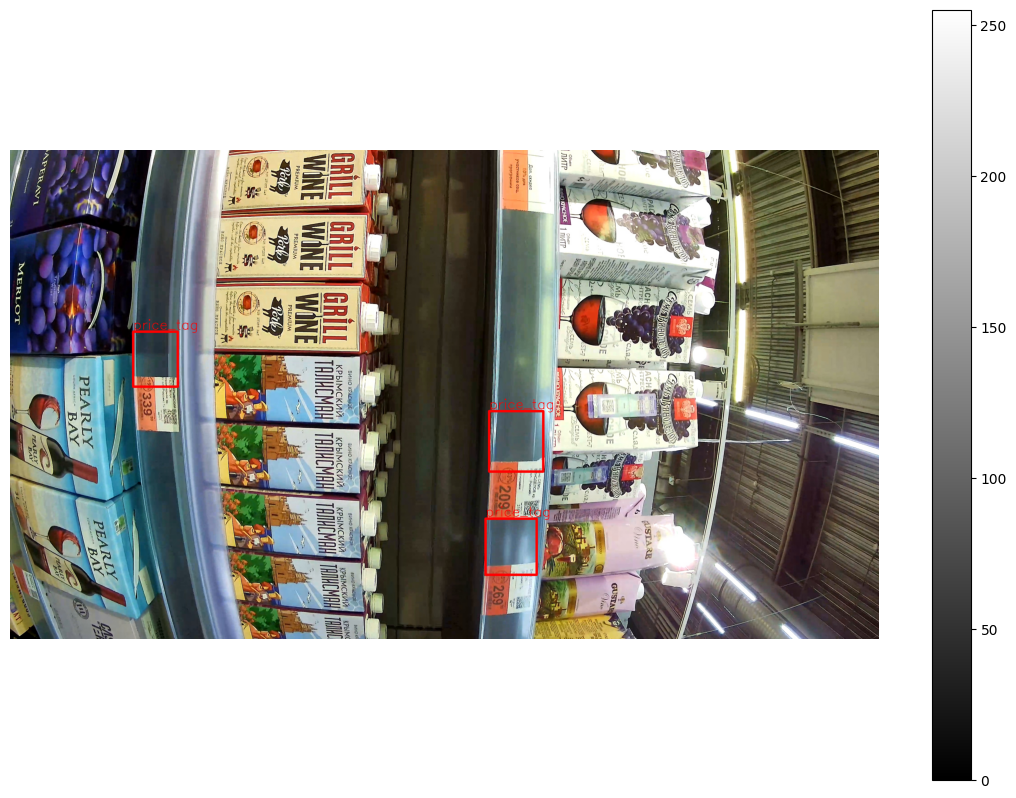

In [ ]:
image_path = '/content/price_tag_yolo/images/25_12-20_ts26334.jpg'
label_path = '/content/price_tag_yolo/labels/25_12-20_ts26334.txt'

demonstrate_train_data(image_path, label_path)

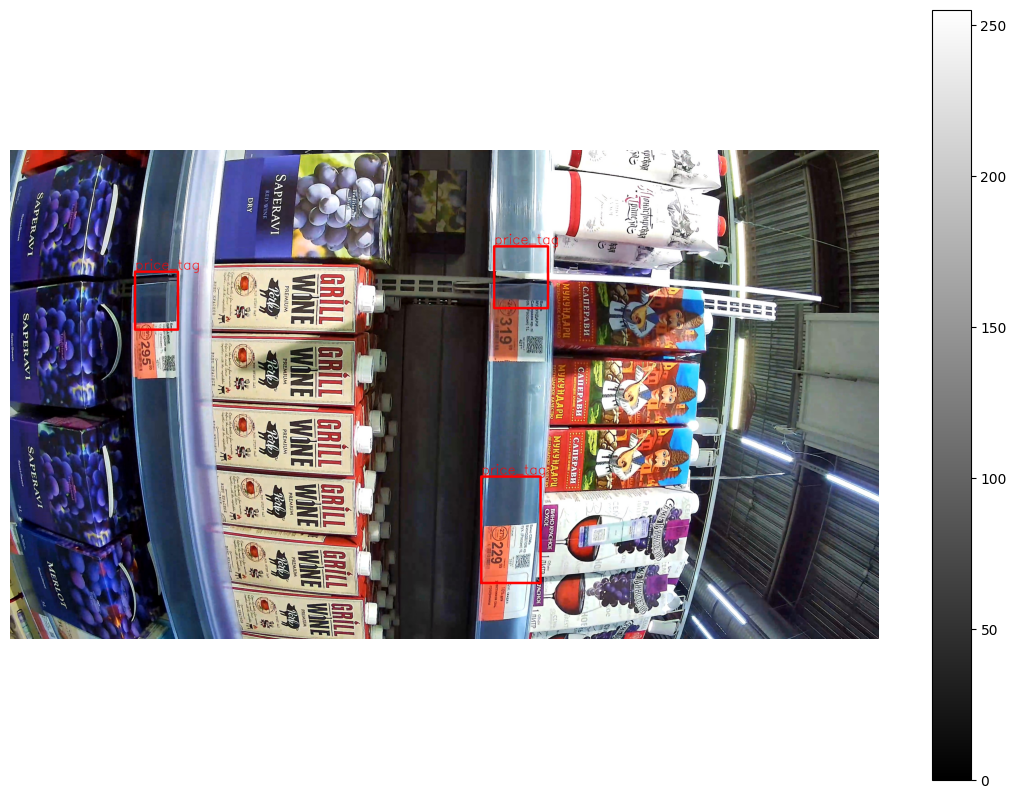

In [ ]:
image_path = '/content/price_tag_yolo/images/25_12-20_ts30401.jpg'
label_path = '/content/price_tag_yolo/labels/25_12-20_ts30401.txt'

demonstrate_train_data(image_path, label_path)